In [1]:
#%%
import math
import numpy as np
import inspect
import importlib

import scipy.interpolate

import matplotlib
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = 16

import plotly.graph_objects as go
import plotly.express as px
import plotly.io as pio
from plotly.offline import plot
pio.renderers.default = "svg"

import sys
import os
parent_directory = os.path.dirname(os.getcwd())
sys.path.append(parent_directory)
#sys.path.append(os.path.dirname(parent_directory))
#sys.path.append(os.path.dirname(os.path.dirname(parent_directory)))

from IoT_node_models.Energy_model                        import *
from IoT_node_models.Energy_model.Wireless_communication import *
from IoT_node_models.Hardware_Modules                    import *
from IoT_node_models.Impact_model                        import *
from IoT_node_models.Analysis                            import *

path_to_save_svg = "Saved_Data"



Importing IoT Node models
Importing IoT Node Energy models
Importing IoT Node Energy models
Importing Wireless communication packages
Importing Wireless communication packages
Importing custom modules data
Importing custom modules data
Importing Impact models
Importing Impact models
Importing IoT Node analysis models


In [2]:
dictColor = {"DeepBlue"     :"#095256",
             "LightBlue"    :"#01a7c2",
             "UnitedBlue"   :"#6290c8",
             "CerulBlue"    :"#6096ba",
             "Green"        :"#44af69",
             "LightRed"     :"#f8333c",
             "DeepRed"      :"#a22c29",
             "Orange"       :"#fcab10",
             "Sandy"        :"#fc9e4F",
             "Olivine"      :"#9ab87a",
             "CarolinaBlue" :"#009DDC"}
listColor = list(dictColor.values())

In [3]:
RX_module_3V3 = Node_module(name="LoRa radio",
                            v=3.3,
                            i_sleep=6e-3)
RX_state_TX_3V3 = Module_state("TX",i = 52,duration = None)
RX_state_RX_3V3 = Module_state("RX",i = 22,duration = None)
RX_module_3V3.add_state(RX_state_TX_3V3)
RX_module_3V3.add_state(RX_state_RX_3V3)


MCU_module_3V3 = Node_module(name="Apollo3",
                            v      =3.3,
                            i_sleep=0)
MCU_state_active_3V3  = Module_state("Active",i = 0,duration = None)
MCU_module_3V3.add_state(MCU_state_active_3V3)

In [4]:
node_LDO = LDO(name = "Node LDO", v_out = 3.3, i_q = 1e-3, v_in = 3.3, module_list = module_List_3V3)
node_Batt= Battery(name = "Node Batt.", v = 3.3, capacity_mAh = 1800, i = 0, selfdischarge_p_year = 5)

node_lora = LoRa_Node(name= "IoT Node", module_list= module_List_3V3, PMU_composition =[node_LDO], Battery = node_Batt, radio_module = radio_module_3V3)

node= LoRa_Node_profile("Node_profile", node_lora,  RX_state=radio_state_RX_3V3,TX_state=radio_state_TX_3V3,
                    P_TX= PTX_PABOOST_configured, I_TX=I_PABoost_3V3 ) 
              
this_task_tx0 = node.create_task_tx(name="TX-0", Ptx = 17,SF=7 ,Coding=1,Header=True,DE = 1,BW = 125e3, Payload = 50, TX_rate=24*1)
this_task_rx0 = node.create_task_rx(name="RX-0", RX_rate=2, RX_duration=0.250 )

this_task_tx1 = node.create_task_tx(name="TX-1", Ptx = 17,SF=12 ,Coding=1,Header=True,DE = 1,BW = 125e3, Payload = 50, TX_rate=24*1)
this_task_rx1 = node.create_task_rx(name="RX-1", RX_rate=10, RX_duration=0.250 )


node.add_task(task_TPHG_3V3,24*12)

In [5]:
def PL_model(d):
    return path_loss_PLd0(d=d, PLd0=94.40,d0=1, n=2.03)

this_task_tx0.set_Path_loss_model(PL_model)
this_task_tx1.set_Path_loss_model(PL_model)


this_task_tx0.set_distance( d= 1500)
this_task_tx1.set_distance( d= 200)

-------------------------------------------------
            Tasks summary                        
-------------------------------------------------
Task name            : Sleep          TX-0           RX-0           TX-1           RX-1           TPHG meas.     
Times/day    [1/d]   : 1              24             2              24             10             288            
Tot. durat.  [s]     : 85709.8762     55.2468        0.5000         3.0781         2.5000         628.7988       
Tot. en./d   [mJ]    : 983.5399       16193.7062     18.6167        602.4927       93.0837        23484.1887     
Node en./d   [mJ]    : 41375.6279      
Average pow. [mW]    : 0.4789          
-------------------------------------------------
-----------------------------------------------------------------
                        Module summary                           
-----------------------------------------------------------------
Module       State        Active [s]   Energy [mJ]  Av. Cur.[uA]  

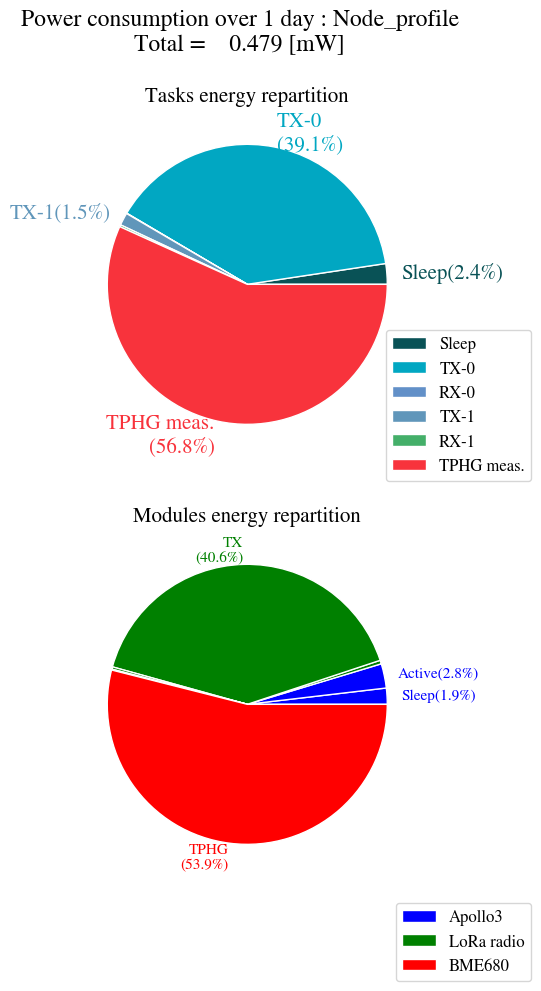

In [6]:

node.compute()
node.print_Tasks()
node.print_Modules()
node.plot_Power()

In [33]:
show = 0

AA_series = 3
AA_footprint = 0.165
AA_cost      = 0.25 
Batt_footprint = AA_series*AA_footprint
Batt_cost      = AA_series*AA_cost

placementNnodes   = 100
decomNnodes       = 100
replacementNnodes = 10

transport_f =   transport_footprint(km_one_way = 10, 
                                    type ="Unit", 
                                    weight_g = 500,  
                                    footprint_p_tkm = 0.545,
                                    unit_factor = 1,
                                    footprint_p_km = 0.350)

transport_c =   transport_cost( worker = 1, salary_p_hour = 20, work_hour =0.3, km_p_h = 50,km_one_way = 10, 
                                type ="Unit", 
                                weight_g = 500, cost_p_tkm =  0.2/1e3,
                                unit_factor = 1,cost_p_km = 0.2)
    

node_footprint = Node_BoM(  casing            =[0.709,    0.3932, 1.3259], #709
                            connectivtiy      =[0.517,    0.2262, 0.5817],
                            eol               =[0.0812,   0.0388, 0.1201],
                            memory            =[0,        0,      0     ],
                            others            =[0.0938,   0.0546, 0.1394],
                            pcb               =[1.17,     0.9403, 1.5696], #1.17
                            power_supply      =[0.132,    0.0446, 0.1751],
                            processing        =[0.366,    0.366,  0.4537],
                            sensing           =[0.0539,   0.0539, 0.5561],
                            ui                =[0.0306,   0.0017, 0.1155],
                            transport         =[transport_f*show,transport_f*show,transport_f*show],
                            battery           =[Batt_footprint  ,Batt_footprint,Batt_footprint],
                            placement         =[transport_f,transport_f,transport_f],
                            replacement       =[transport_f,transport_f,transport_f],
                            decom             =[transport_f,transport_f,transport_f], 
                            placementNnodes   = placementNnodes,
                            decomNnodes       = decomNnodes,
                            replacementNnodes = replacementNnodes)


node_Cost   = Node_BoM(     casing            =[10    ,    0 , 0], #ABS , IP rated
                            connectivtiy      =[5.3   ,    0 , 0], #SX1276 : 5.3
                            eol               =[0     ,    0 , 0],
                            memory            =[0     ,    0 , 0],
                            others            =[1.42  ,    0 , 0], #MLCC : 0.05*15 + XTAL32MHz: 0.5 + R: 0.002*15 + D : 0.07*2  
                            pcb               =[1.17  ,    0 , 0], #PCB 60cm2 : 1.75 
                            power_supply      =[0.228 ,    0 , 0], #XC6206 : 0.228 + Diode and Transistor?
                            processing        =[3.65  ,    0 , 0], #Apollo3: 3.65
                            sensing           =[6.94  ,    0 , 0], #BME680 : 6.94
                            ui                =[0.54  ,    0 , 0], #Push button : 0.17*2 + LED SMD : 0.2*1
                            transport         =[transport_c,0 , 0],
                            battery           =[Batt_cost  ,0 , 0],
                            placement         =[transport_c,0 , 0],
                            replacement       =[transport_c,0 , 0],
                            decom             =[transport_c,0 , 0],
                            placementNnodes   = 100,
                            decomNnodes       = 100,
                            replacementNnodes = 10)


3.6485000000000003


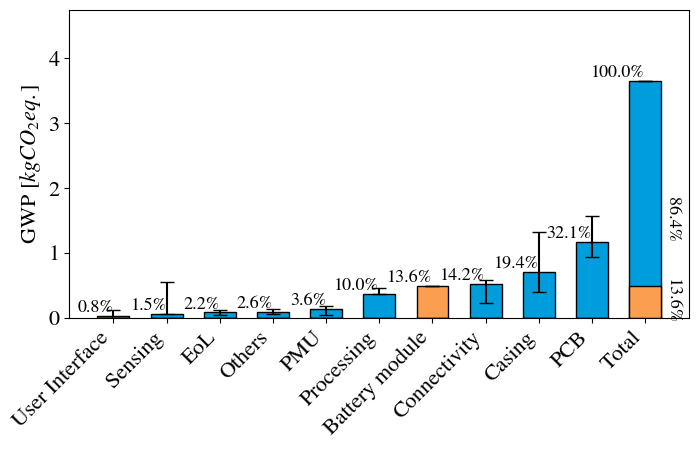

In [34]:
node_footprint.plot_footprint(filename = None ,figsize =(8,4),separatePlot=False)

In [9]:
[res1,res2,lifetime,residue] =deployment_battery_replacement(
                                    Replacement_type = "Complete",
                                    Footprint=node_footprint,
                                    Node=node,
                                    Nyears= 20)
print([res1,res2,lifetime,residue])

[10.356300000000003, np.float64(9.874004488483266), np.float64(1.313886939293219), np.float64(0.47888458229306524)]


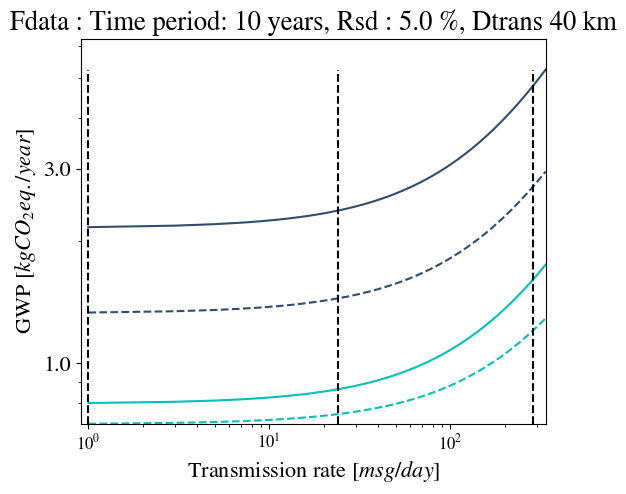

In [10]:

deployment_sweep_fdata(Replacement_strategy = "Both", 
                       Footprint=node_footprint,
                       Node=node,
                       Nyears=10,
                       dtrans=40,
                       nAA = [1,4]  , 
                       param = [200]   , 
                       paramType ="dnode",
                       fmax=24*12+50, 
                       f_step=2         ,
                       Task = task_TPHG_3V3,
                       transport_model=F_trans, 
                       filename = None            ,figsize =(6,5) )

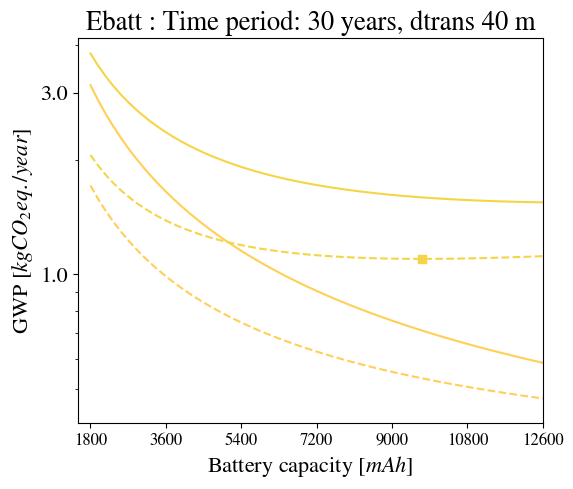

In [11]:

n_years = 30                       
km_trans = 40

node.change_task_rate(task_TPHG_3V3,24*12)
this_task_tx0.set_distance(d= 700)

deployment_sweep_ebatt(Replacement_strategy = "Both", 
                       Footprint=node_footprint,
                       Node=node,
                       Nyears=n_years,
                       dtrans=km_trans,
                       param = [0,10] , 
                       paramType ="rsd",
                       nAAmin = 1, 
                       nAAmax=7, 
                       nAA_step=0.1 ,
                       transport_model=F_trans, 
                       filename = None      ,figsize =(6,5) )
    

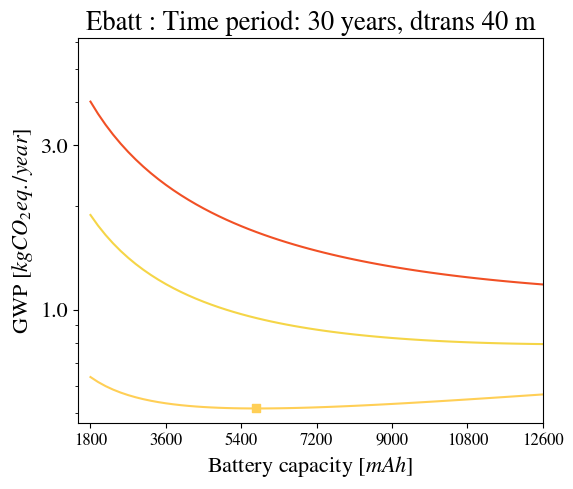

In [15]:

n_years = 30                       
km_trans = 40

node.change_task_rate(task_TPHG_3V3,24*12)
this_task_tx0.set_distance(d= 700)

deployment_sweep_ebatt(Replacement_strategy = "Battery", 
                       Footprint=node_footprint,
                       Node=node,
                       Nyears=n_years,
                       dtrans=km_trans,
                       param = [5,40,100] , 
                       paramType ="dtrans",
                       nAAmin = 1, 
                       nAAmax=7, 
                       nAA_step=0.1 ,
                       transport_model=F_trans, 
                       filename = None      ,figsize =(6,5) )
    

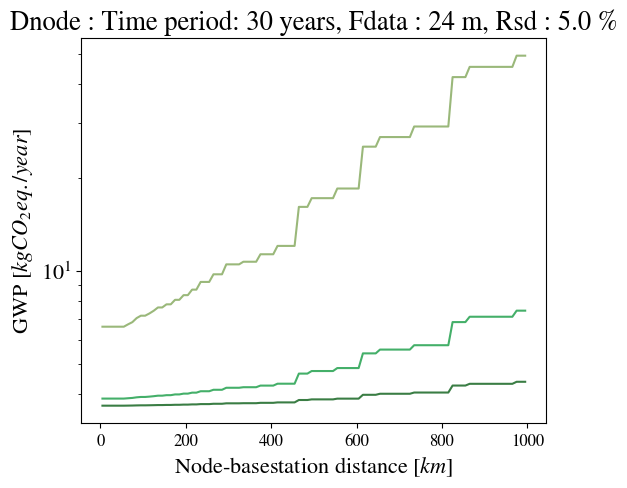

In [27]:

n_years = 30                       
km_trans = 40

node.change_task_rate(task_TPHG_3V3,24*12)
this_task_tx0.set_distance(d= 700)

deployment_sweep_dnode  (Replacement_strategy = "Battery", 
                        Footprint=node_footprint,
                        Node=node,
                        Nyears=n_years,
                        param = [24,24*5,24*60], 
                        paramType ="fdata",
                        dmin = 5, 
                        dmax=1000, 
                        d_step=10, 
                        Task_tx = this_task_tx0,
                        PL_model=None,
                        filename=None,
                        figsize=(6,5))  
